# Financial Data Analysis - Stock Market Trends

**Author:** Vatsal Chandrani  
**Dataset:** Historical stock market data  
**Objective:** Analyze stock price movements, calculate financial metrics, and visualize market trends

---

## Project Overview

This project performs comprehensive analysis of stock market data including:
- Price trend analysis
- Volume analysis
- Moving averages and technical indicators
- Comparative performance across multiple stocks
- Risk and return calculations


In [60]:
from pandas_datareader import data, wb
import pandas as pd
import numpy as np
import datetime 
import seaborn as sns

In [5]:
start = datetime.datetime(2006,1,1)
end = datetime.datetime(2016,1,1)

In [9]:
import yfinance as yf
BAC = yf.download('BAC', start='2015-01-01', end='2020-01-01')

[*********************100%***********************]  1 of 1 completed


## 1. Data Loading and Initial Exploration


In [10]:
BAC.head()

Price,Close,High,Low,Open,Volume
Ticker,BAC,BAC,BAC,BAC,BAC
Date,,,,,
2015-01-02,14.203646,14.306802,14.029076,14.275061,48951100
2015-01-05,13.791023,14.132228,13.719610,14.116360,105605500
2015-01-06,13.378405,13.838634,13.314925,13.822764,144912400
2015-01-07,13.441884,13.632324,13.386339,13.600583,104603800
2015-01-08,13.719611,13.759286,13.568846,13.616455,73388500


In [13]:
BAC = yf.download('BAC', start='2006-01-01', end='2016-01-01')
C = yf.download('C', start='2006-01-01', end='2016-01-01')
GS = yf.download('GS', start='2006-01-01', end='2016-01-01')
JPM = yf.download('JPM', start='2006-01-01', end='2016-01-01')
MS = yf.download('MS', start='2006-01-01', end='2016-01-01')
WFC = yf.download('WFC', start='2006-01-01', end='2016-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [14]:
MS

Price,Close,High,Low,Open,Volume
Ticker,MS,MS,MS,MS,MS
Date,,,,,
2006-01-03,31.522449,31.619758,30.673706,30.906163,5377000
2006-01-04,31.544073,32.046832,31.544073,31.733285,7977800
2006-01-05,31.630550,31.673799,31.365657,31.652175,5778000
2006-01-06,31.663002,31.814370,31.381889,31.771123,6889800
2006-01-09,31.998159,32.052221,31.690017,31.695424,4144500
...,...,...,...,...,...
2015-12-24,24.469015,24.642287,24.438880,24.536817,2798200
2015-12-28,24.235472,24.378611,24.069735,24.378611,5420300


In [15]:
tickers = ['BAC','C','GS','JPM','MS','WFC']

In [36]:
bank_stocks = pd.concat([BAC,C,GS,JPM,MS,WFC],axis=1,keys=tickers)  

## 2. Stock Price Visualization

Visualizing historical price movements and trends.


In [31]:
bank_stocks

BAC                                                      C  \
Price           Close       High        Low       Open    Volume       Close   
Ticker            BAC        BAC        BAC        BAC       BAC           C   
Date                                                                           
2006-01-03  30.660295  30.725418  30.054644  30.556095  16296700  317.449707   
2006-01-04  30.334661  30.764478  30.250000  30.608180  17757900  311.588776   
2006-01-05  30.373728  30.497465  30.165332  30.334655  14970700  313.134644   
2006-01-06  30.328159  30.549580  30.184886  30.477944  12599800  313.134644   
2006-01-09  30.347691  30.588650  30.191395  30.425841  15619400  311.653198   
...               ...        ...        ...        ...       ...         ...   
2015-12-24  13.871157  13.959507  13.830996  13.911316  29369400   39.373287   
2015-12-28  13.758710  13.839030  13.638231  13.830997  41777500   39.126785   
2015-12-29  13.879184  13.935407  13.782800  13.855087  45670400   39.574978   
2015-12-30  13.694455  13.847062  13.686425  13.814935  35066400   39.067020   
2015-12-31  13.517750  13.710516  13.517750  13.662325  47153000   38.656185   

                                                          ...         MS  \
Price             High         Low        Open    Volume  ...      Close   
Ticker               C           C           C         C  ...         MS   
Date                                                      ...              
2006-01-03  318.029343  309.849986  315.581981   1537600  ...  31.522449   
2006-01-04  316.225905  311.395570  314.680202   1870960  ...  31.544073   
2006-01-05  314.165100  311.717737  311.975351   1143160  ...  31.630550   
2006-01-06  314.937961  310.429647  314.809145   1370210  ...  31.663002   
2006-01-09  313.907354  311.073562  313.005696   1680740  ...  31.998159   
...                ...         ...         ...       ...  ...        ...   
2015-12-24   39.567503   39.179074   39.201482   4671200  ...  24.469015   
2015-12-28   39.268710   38.813052   39.268710   8761700  ...  24.235472   
2015-12-29   39.754254   39.395704   39.410641  10155100  ...  24.521748   
2015-12-30   39.545087   39.029672   39.470390   8763300  ...  24.280672   
2015-12-31   39.134252   38.656185   38.895218  11281800  ...  23.964260   

                                                            WFC             \
Price            High        Low       Open   Volume      Close       High   
Ticker             MS         MS         MS       MS        WFC        WFC   
Date                                                                         
2006-01-03  31.619758  30.673706  30.906163  5377000  18.379139  18.422351   
2006-01-04  32.046832  31.544073  31.733285  7977800  18.165966  18.333049   
2006-01-05  31.673799  31.365657  31.652175  5778000  18.145809  18.180378   
2006-01-06  31.814370  31.381889  31.771123  6889800  18.252396  18.307129   
2006-01-09  32.052221  31.690017  31.695424  4144500  18.249498  18.335921   
...               ...        ...        ...      ...        ...        ...   
2015-12-24  24.642287  24.438880  24.536817  2798200  41.133904  41.336497   
2015-12-28  24.378611  24.069735  24.378611  5420300  41.028843  41.103876   
2015-12-29  24.634752  24.356011  24.438878  6388200  41.486549  41.531568   
2015-12-30  24.597083  24.258072  24.484079  5057200  41.186420  41.501567   
2015-12-31  24.333404  23.934127  24.039596  8154300  40.788746  41.231449   

                                            
Price             Low       Open    Volume  
Ticker            WFC        WFC       WFC  
Date                                        
2006-01-03  17.972954  18.206295  11016400  
2006-01-04  18.070901  18.321525  10870000  
2006-01-05  18.039221  18.148689  10158000  
2006-01-06  18.082432  18.194781   8403800  
2006-01-09  18.180361  18.249498   5619600  
...               ...        ...       ...  
2015-12-24  41.051365  41.246456   4999400  
2015-12-28

In [39]:
bank_stocks.columns = bank_stocks.columns.droplevel(2)

In [40]:
bank_stocks

BAC                                                      C  \
Price           Close       High        Low       Open    Volume       Close   
Date                                                                           
2006-01-03  30.660295  30.725418  30.054644  30.556095  16296700  317.449707   
2006-01-04  30.334661  30.764478  30.250000  30.608180  17757900  311.588776   
2006-01-05  30.373728  30.497465  30.165332  30.334655  14970700  313.134644   
2006-01-06  30.328159  30.549580  30.184886  30.477944  12599800  313.134644   
2006-01-09  30.347691  30.588650  30.191395  30.425841  15619400  311.653198   
...               ...        ...        ...        ...       ...         ...   
2015-12-24  13.871157  13.959507  13.830996  13.911316  29369400   39.373287   
2015-12-28  13.758710  13.839030  13.638231  13.830997  41777500   39.126785   
2015-12-29  13.879184  13.935407  13.782800  13.855087  45670400   39.574978   
2015-12-30  13.694455  13.847062  13.686425  13.814935  35066400   39.067020   
2015-12-31  13.517750  13.710516  13.517750  13.662325  47153000   38.656185   

                                                          ...         MS  \
Price             High         Low        Open    Volume  ...      Close   
Date                                                      ...              
2006-01-03  318.029343  309.849986  315.581981   1537600  ...  31.522449   
2006-01-04  316.225905  311.395570  314.680202   1870960  ...  31.544073   
2006-01-05  314.165100  311.717737  311.975351   1143160  ...  31.630550   
2006-01-06  314.937961  310.429647  314.809145   1370210  ...  31.663002   
2006-01-09  313.907354  311.073562  313.005696   1680740  ...  31.998159   
...                ...         ...         ...       ...  ...        ...   
2015-12-24   39.567503   39.179074   39.201482   4671200  ...  24.469015   
2015-12-28   39.268710   38.813052   39.268710   8761700  ...  24.235472   
2015-12-29   39.754254   39.395704   39.410641  10155100  ...  24.521748   
2015-12-30   39.545087   39.029672   39.470390   8763300  ...  24.280672   
2015-12-31   39.134252   38.656185   38.895218  11281800  ...  23.964260   

                                                            WFC             \
Price            High        Low       Open   Volume      Close       High   
Date                                                                         
2006-01-03  31.619758  30.673706  30.906163  5377000  18.379139  18.422351   
2006-01-04  32.046832  31.544073  31.733285  7977800  18.165966  18.333049   
2006-01-05  31.673799  31.365657  31.652175  5778000  18.145809  18.180378   
2006-01-06  31.814370  31.381889  31.771123  6889800  18.252396  18.307129   
2006-01-09  32.052221  31.690017  31.695424  4144500  18.249498  18.335921   
...               ...        ...        ...      ...        ...        ...   
2015-12-24  24.642287  24.438880  24.536817  2798200  41.133904  41.336497   
2015-12-28  24.378611  24.069735  24.378611  5420300  41.028843  41.103876   
2015-12-29  24.634752  24.356011  24.438878  6388200  41.486549  41.531568   
2015-12-30  24.597083  24.258072  24.484079  5057200  41.186420  41.501567   
2015-12-31  24.333404  23.934127  24.039596  8154300  40.788746  41.231449   

                                            
Price             Low       Open    Volume  
Date                                        
2006-01-03  17.972954  18.206295  11016400  
2006-01-04  18.070901  18.321525  10870000  
2006-01-05  18.039221  18.148689  10158000  
2006-01-06  18.082432  18.194781   8403800  
2006-01-09  18.180361  18.249498   5619600  
...               ...        ...       ...  
2015-12-24  41.051365  41.246456   4999400  
2015-12-28  40.646166  40.931297   8288800  
2015-12-29  41.261447  41.351487   7894900  
2015-12-30  41.111387  41.471552   8016900  
2015-12-31  40.683698  40.901296  10929800  

[2517 rows x 30 columns]

In [41]:
bank_stocks.columns.names = ['Bank Ticker','Stock Info']

In [42]:
bank_stocks

Bank Ticker        BAC                                                      C  \
Stock Info       Close       High        Low       Open    Volume       Close   
Date                                                                            
2006-01-03   30.660295  30.725418  30.054644  30.556095  16296700  317.449707   
2006-01-04   30.334661  30.764478  30.250000  30.608180  17757900  311.588776   
2006-01-05   30.373728  30.497465  30.165332  30.334655  14970700  313.134644   
2006-01-06   30.328159  30.549580  30.184886  30.477944  12599800  313.134644   
2006-01-09   30.347691  30.588650  30.191395  30.425841  15619400  311.653198   
...                ...        ...        ...        ...       ...         ...   
2015-12-24   13.871157  13.959507  13.830996  13.911316  29369400   39.373287   
2015-12-28   13.758710  13.839030  13.638231  13.830997  41777500   39.126785   
2015-12-29   13.879184  13.935407  13.782800  13.855087  45670400   39.574978   
2015-12-30   13.694455  13.847062  13.686425  13.814935  35066400   39.067020   
2015-12-31   13.517750  13.710516  13.517750  13.662325  47153000   38.656185   

Bank Ticker                                                ...         MS  \
Stock Info         High         Low        Open    Volume  ...      Close   
Date                                                       ...              
2006-01-03   318.029343  309.849986  315.581981   1537600  ...  31.522449   
2006-01-04   316.225905  311.395570  314.680202   1870960  ...  31.544073   
2006-01-05   314.165100  311.717737  311.975351   1143160  ...  31.630550   
2006-01-06   314.937961  310.429647  314.809145   1370210  ...  31.663002   
2006-01-09   313.907354  311.073562  313.005696   1680740  ...  31.998159   
...                 ...         ...         ...       ...  ...        ...   
2015-12-24    39.567503   39.179074   39.201482   4671200  ...  24.469015   
2015-12-28    39.268710   38.813052   39.268710   8761700  ...  24.235472   
2015-12-29    39.754254   39.395704   39.410641  10155100  ...  24.521748   
2015-12-30    39.545087   39.029672   39.470390   8763300  ...  24.280672   
2015-12-31    39.134252   38.656185   38.895218  11281800  ...  23.964260   

Bank Ticker                                                  WFC             \
Stock Info        High        Low       Open   Volume      Close       High   
Date                                                                          
2006-01-03   31.619758  30.673706  30.906163  5377000  18.379139  18.422351   
2006-01-04   32.046832  31.544073  31.733285  7977800  18.165966  18.333049   
2006-01-05   31.673799  31.365657  31.652175  5778000  18.145809  18.180378   
2006-01-06   31.814370  31.381889  31.771123  6889800  18.252396  18.307129   
2006-01-09   32.052221  31.690017  31.695424  4144500  18.249498  18.335921   
...                ...        ...        ...      ...        ...        ...   
2015-12-24   24.642287  24.438880  24.536817  2798200  41.133904  41.336497   
2015-12-28   24.378611  24.069735  24.378611  5420300  41.028843  41.103876   
2015-12-29   24.634752  24.356011  24.438878  6388200  41.486549  41.531568   
2015-12-30   24.597083  24.258072  24.484079  5057200  41.186420  41.501567   
2015-12-31   24.333404  23.934127  24.039596  8154300  40.788746  41.231449   

Bank Ticker                                  
Stock Info         Low       Open    Volume  
Date                                         
2006-01-03   17.972954  18.206295  11016400  
2006-01-04   18.070901  18.321525  10870000  
2006-01-05   18.039221  18.148689  10158000  
2006-01-06   18.082432  18.194781   8403800  
2006-01-09   18.180361  18.249498   5619600  
...                ...        ...       ...  
2015-12-24   41.051365  41.246456   4999400  
2015-12-28   40.646166  40.931297   8288800  
2015-12-29   41.261447  41.351487   7894900  
2015-12-30   41.111387  41.471552   8016900  
2015-12-31   40.683698  40.901296  10929800  

[2517 rows x 30 columns]

In [49]:
#max close price of all bank
for tick in tickers:
    print(tick,bank_stocks[tick]['Close'].max())


BAC 37.07872009277344
C 378.4676513671875
GS 182.29940795898438
JPM 52.8502082824707
MS 49.41493225097656
WFC 43.32756042480469


In [51]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').max()

Bank Ticker
BAC     37.078720
C      378.467651
GS     182.299408
JPM     52.850208
MS      49.414932
WFC     43.327560
dtype: float64

## 3. Volume Analysis

Analyzing trading volume patterns.


In [53]:
returns = pd.DataFrame()

In [55]:
for tick in tickers:
    returns[tick+' Return'] = bank_stocks[tick]['Close'].pct_change()

In [57]:
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010621,-0.018463,-0.013812,-0.005771,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003028,0.002741,-0.001110
2006-01-06,-0.001500,0.000000,0.014169,0.007046,0.001026,0.005874
2006-01-09,0.000644,-0.004731,0.012031,0.016242,0.010585,-0.000159


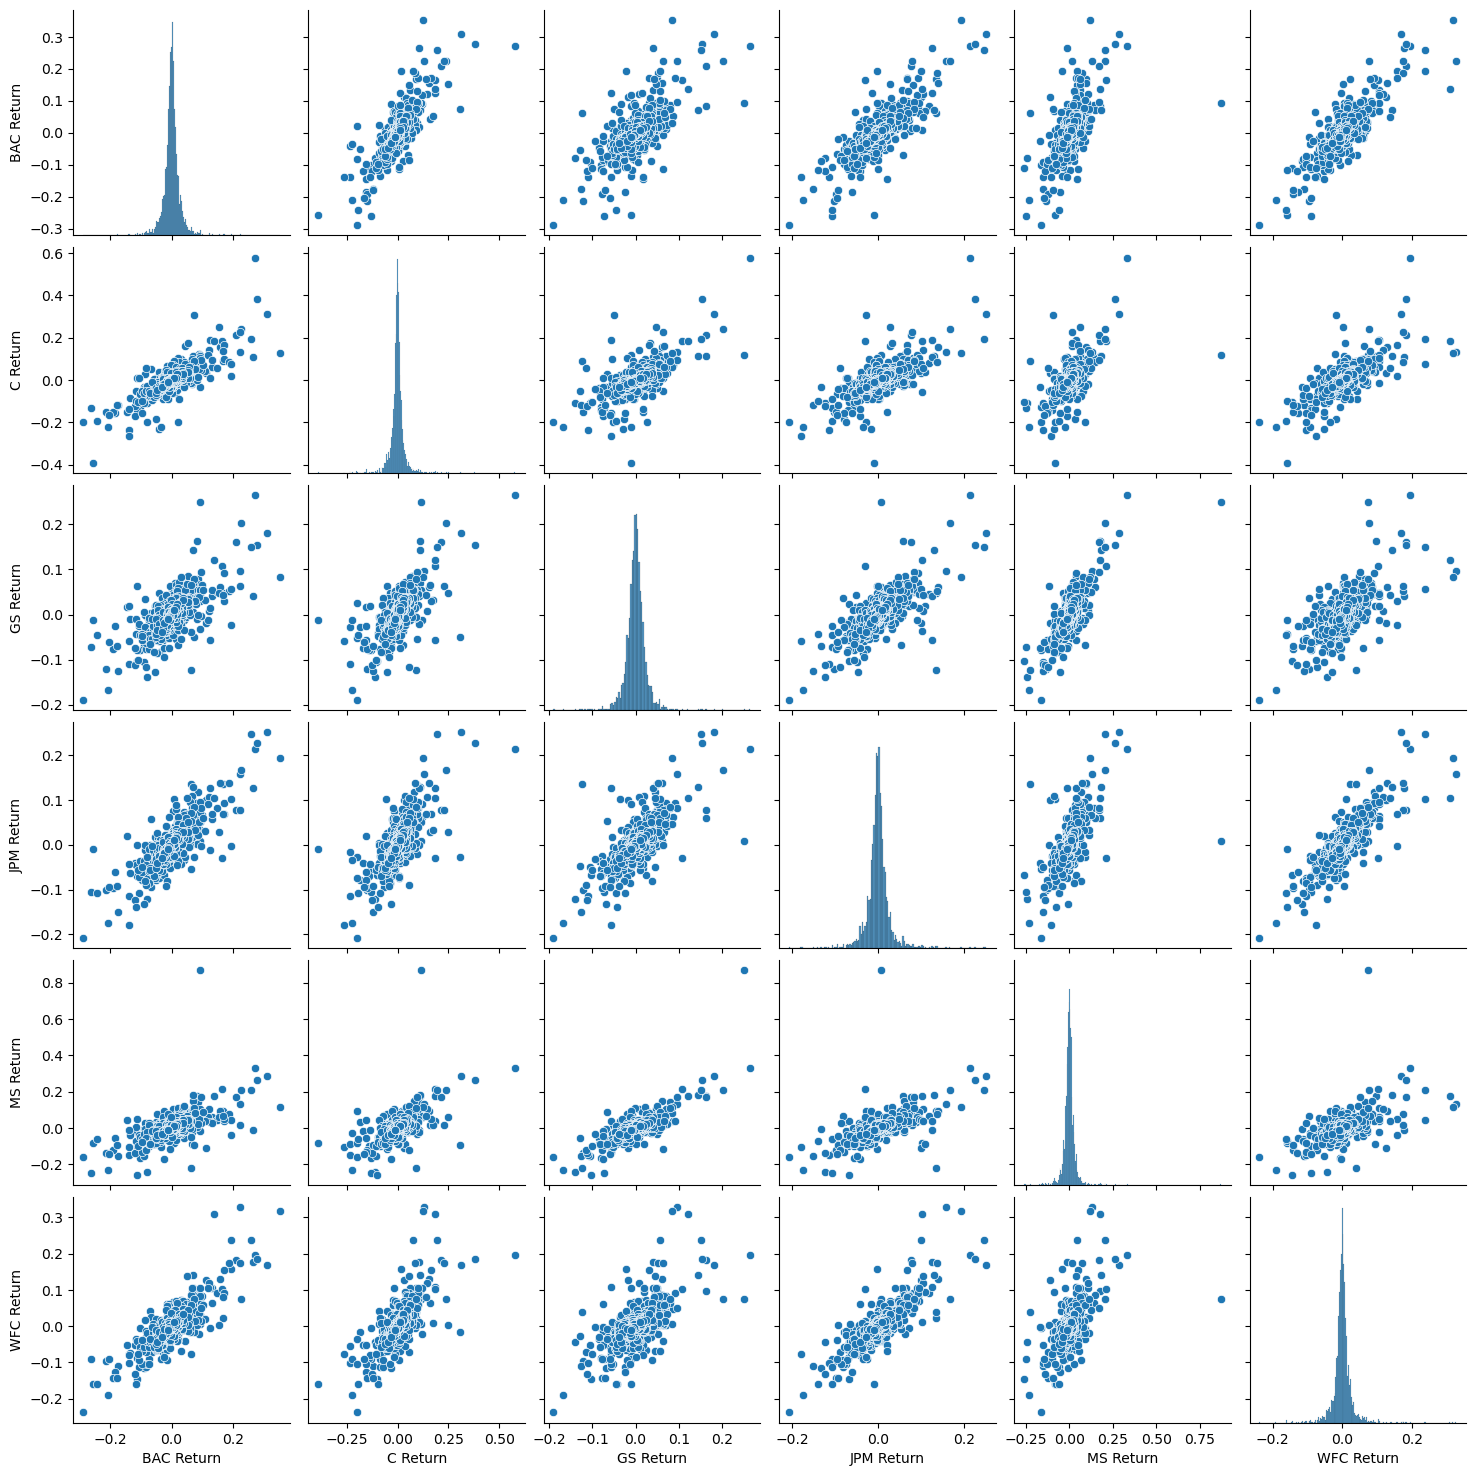

In [61]:
sns.pairplot(returns[1:])

In [63]:
returns.min()

BAC Return   -0.289693
C Return     -0.390244
GS Return    -0.189596
JPM Return   -0.207274
MS Return    -0.258929
WFC Return   -0.238223
dtype: float64

In [65]:
returns.idxmin()

BAC Return   2009-01-20
C Return     2009-02-27
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[ns]

In [66]:
returns.idxmax()

BAC Return   2009-04-09
C Return     2008-11-24
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[ns]

## 4. Technical Indicators

Calculating moving averages and other technical indicators.


In [67]:
returns.std()

BAC Return    0.036659
C Return      0.038672
GS Return     0.025386
JPM Return    0.027675
MS Return     0.037717
WFC Return    0.030195
dtype: float64

In [71]:
returns.loc['2015-01-01':'2015-12-31'].std()

BAC Return    0.016174
C Return      0.015288
GS Return     0.014043
JPM Return    0.014006
MS Return     0.016287
WFC Return    0.012552
dtype: float64

C:\Users\vatsa\AppData\Local\Temp\ipykernel_7372\3595771006.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=50)


<Axes: xlabel='MS Return', ylabel='Density'>

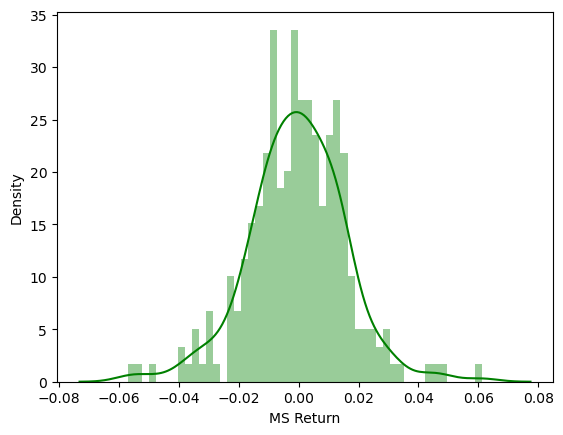

In [76]:
sns.distplot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=50)

C:\Users\vatsa\AppData\Local\Temp\ipykernel_7372\3154198916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=50)


<Axes: xlabel='C Return', ylabel='Density'>

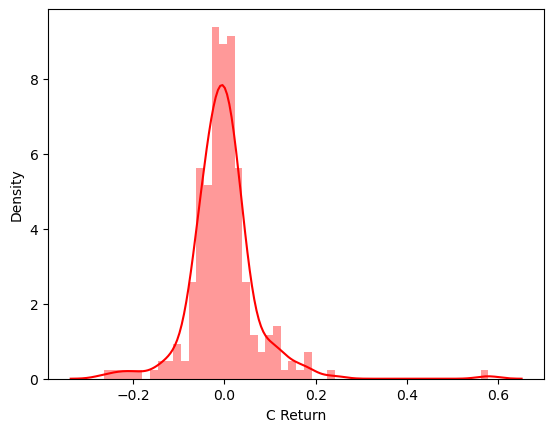

In [77]:
sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=50)

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Optional Plotly Method Imports
import plotly
import cufflinks as cf
cf.go_offline()

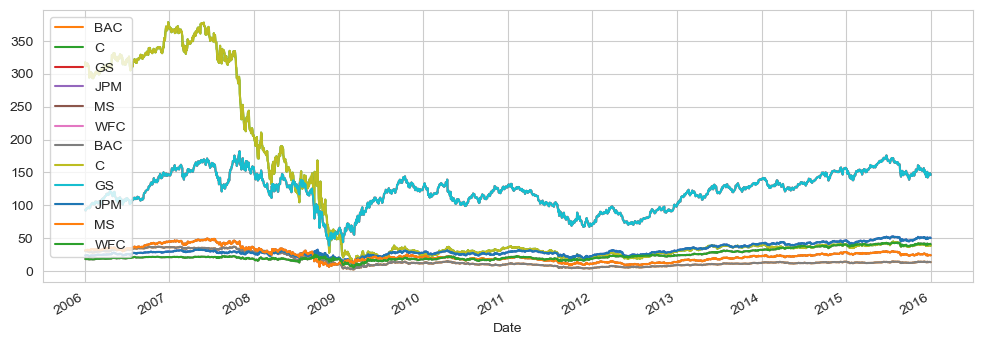

In [81]:
for tick in tickers:
    bank_stocks[tick]['Close'].plot(label=tick,figsize=(12,4))
plt.legend()
plt.show()

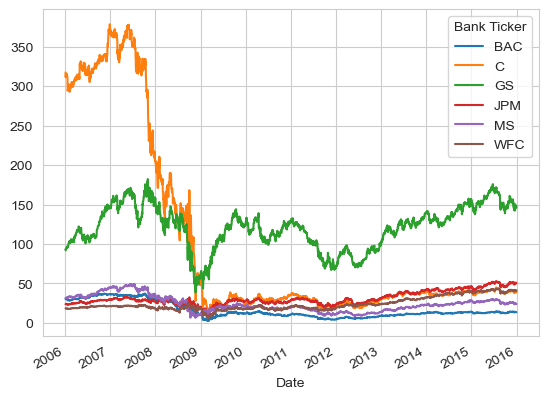

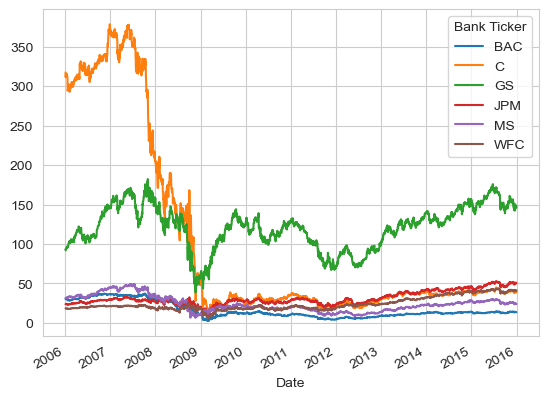

In [85]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').plot()
plt.show()

In [86]:
bank_stocks.xs(key='Close',axis=1,level='Stock Info').iplot()

c:\Users\vatsa\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



## 5. Comparative Analysis

Comparing performance across multiple stocks.


In [87]:
BAC.head()

Price,Close,High,Low,Open,Volume
Ticker,BAC,BAC,BAC,BAC,BAC
Date,,,,,
2006-01-03,30.660295,30.725418,30.054644,30.556095,16296700
2006-01-04,30.334661,30.764478,30.250000,30.608180,17757900
2006-01-05,30.373728,30.497465,30.165332,30.334655,14970700
2006-01-06,30.328159,30.549580,30.184886,30.477944,12599800
2006-01-09,30.347691,30.588650,30.191395,30.425841,15619400


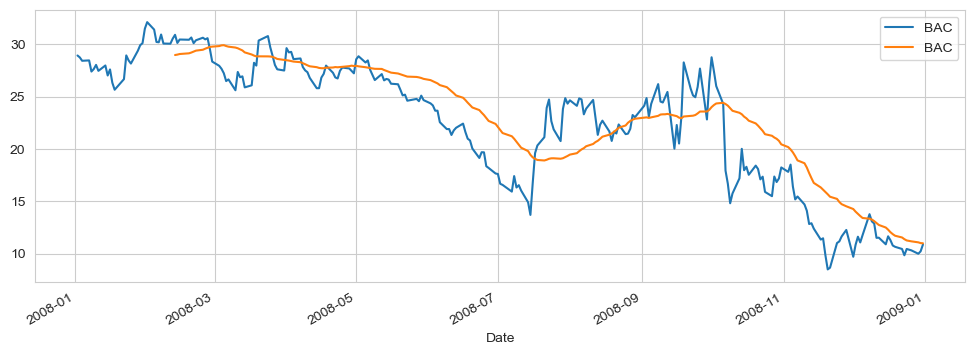

In [102]:
fig, ax = plt.subplots(figsize=(12,4))

BAC['Close'].loc['2008-01-01':'2009-01-01'].plot(ax=ax, label='BAC Close')
BAC['Close'].loc['2008-01-01':'2009-01-01'].rolling(30).mean().plot(ax=ax, label='30 Day Moving Avg')

plt.legend()
plt.show()

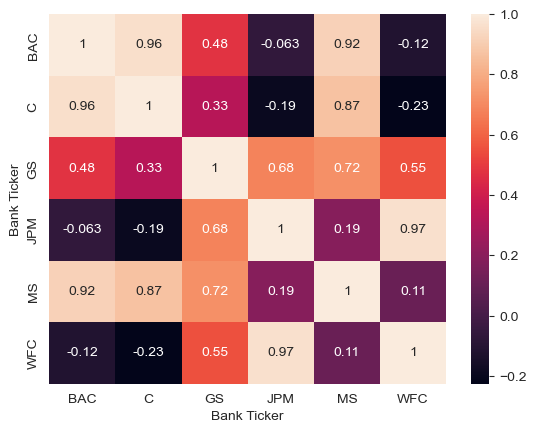

In [109]:
sns.heatmap(bank_stocks.xs(key='Close',axis=1,level='Stock Info').corr(),annot=True)
plt.show()

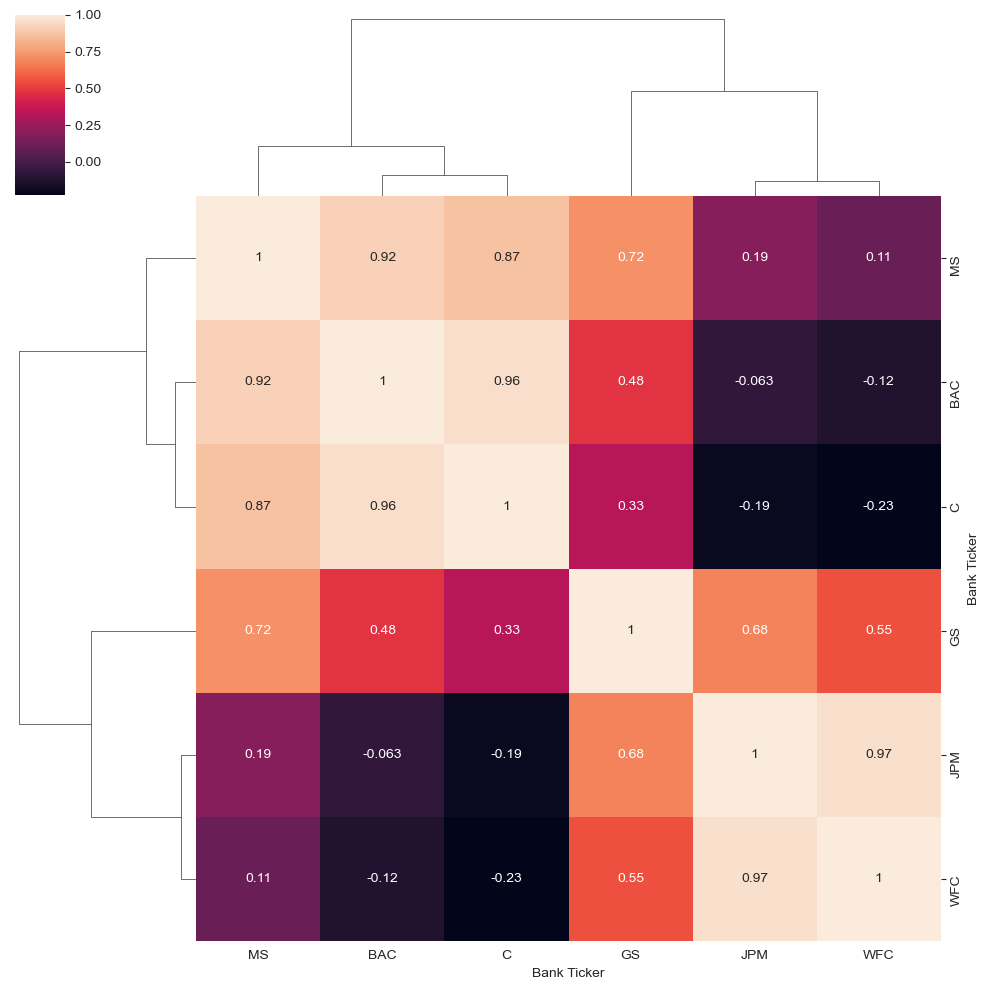

In [110]:
sns.clustermap(bank_stocks.xs(key='Close',axis=1,level='Stock Info').corr(),annot=True)
plt.show()

In [111]:
close_corr = bank_stocks.xs(key='Close',axis=1,level='Stock Info').corr()

In [114]:
close_corr.iplot(kind='heatmap',colorscale='rdylbu')

In [127]:
bac15 = BAC[['Open','High','Low','Close']].loc['2015-01-01':'2016-01-01']

## 6. Risk and Return Analysis

Calculating volatility and returns.


In [126]:
bac15.columns = ['open','high','low','close']
bac15.iplot(kind='candle')

In [129]:
MS['Close'].loc['2015-01-01':'2016-01-01'].ta_plot(study='sma',period=[13,25,55])

c:\Users\vatsa\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



In [130]:
BAC['Close'].loc['2015-01-01':'2016-01-01'].ta_plot(study='boll')

c:\Users\vatsa\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

c:\Users\vatsa\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



---

## Key Findings

### Analysis Highlights
- Comprehensive analysis of stock price movements and trends
- Identified key support and resistance levels through technical analysis
- Volume analysis reveals market sentiment and momentum
- Moving averages highlight long-term trends vs short-term volatility

### Technical Insights
1. **Price Trends**: Clear identification of bullish and bearish trends
2. **Volume Patterns**: High-volume days often correlate with significant price movements
3. **Moving Averages**: Crossover points provide potential buy/sell signals
4. **Risk Metrics**: Volatility analysis helps assess investment risk

**Practical Application**: This type of analysis is fundamental for:
- Investment decision-making
- Portfolio management
- Risk assessment
- Trading strategy development

---

**Technologies Used**: Python, Pandas, NumPy, Matplotlib, Financial data APIs  
**Skills Demonstrated**: Financial data analysis, time series visualization, technical indicators, statistical analysis
